In [ ]:
!pip install torch torchvision torchaudio
!pip install transformers

In [ ]:
import re
import torch
import random
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, logging, AutoModel
from tqdm import tqdm
import os
logging.set_verbosity_error()

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "google-bert/bert-base-multilingual-uncased"
MAX_LEN = 298
BATCH_SIZE = 16

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+\.\S+/\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        enc = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        )

        self.input_ids = enc["input_ids"]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.input_ids[idx]),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=300, hidden_dim=256, num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()
        pad_id = tokenizer.pad_token_id
        if pad_id is None:
            pad_id = 0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)

        _, (hidden, _) = self.lstm(x)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        out = torch.cat([forward_hidden, backward_hidden], dim=1)
        out = self.dropout(out)

        return self.fc(out)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/Colab Notebooks/Семинар/data/"

In [ ]:
train_df = pd.read_parquet(f"{path}train.parquet")
val_df = pd.read_parquet(f"{path}val.parquet")
test_df = pd.read_parquet(f"{path}test.parquet")

In [ ]:
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [ ]:
def train_lstm(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for input_ids, labels in tqdm(loader, desc="Training", leave=False):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out = model(input_ids)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
from sklearn.metrics import f1_score

def evaluate_lstm(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_dataset = TextDataset(train_df['text'].tolist(), train_df['target'].tolist(), tokenizer)
val_dataset   = TextDataset(val_df['text'].tolist(), val_df['target'].tolist(),   tokenizer)
test_dataset  = TextDataset(test_df['text'].tolist(), test_df['target'].tolist(),  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, num_workers=2)

In [ ]:
model = LSTMModel(vocab_size=len(tokenizer)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []
epochs_range = []

best_val_acc = 0
for epoch in range(3):
    train_loss = train_lstm(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_f1 = evaluate_lstm(model, val_loader, criterion, DEVICE)
    print(f"Epoch {epoch+1} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_lstm.pt")

    epochs_range.append(epoch + 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)

print("\n=== Тест ===")
model.load_state_dict(torch.load("best_lstm.pt"))
test_loss, test_acc, test_f1 = evaluate_lstm(model, test_loader, criterion, DEVICE)
print(f"test_acc = {test_acc:.4f} | test_f1 = {test_f1:.4f}")

Epoch 1 | train_loss=0.4841 | val_acc=0.7965 | val_f1=0.7964


Epoch 2 | train_loss=0.3826 | val_acc=0.8077 | val_f1=0.8076


Epoch 3 | train_loss=0.3122 | val_acc=0.8048 | val_f1=0.8047

=== Тест ===
test_acc = 0.8088 | test_f1 = 0.8088


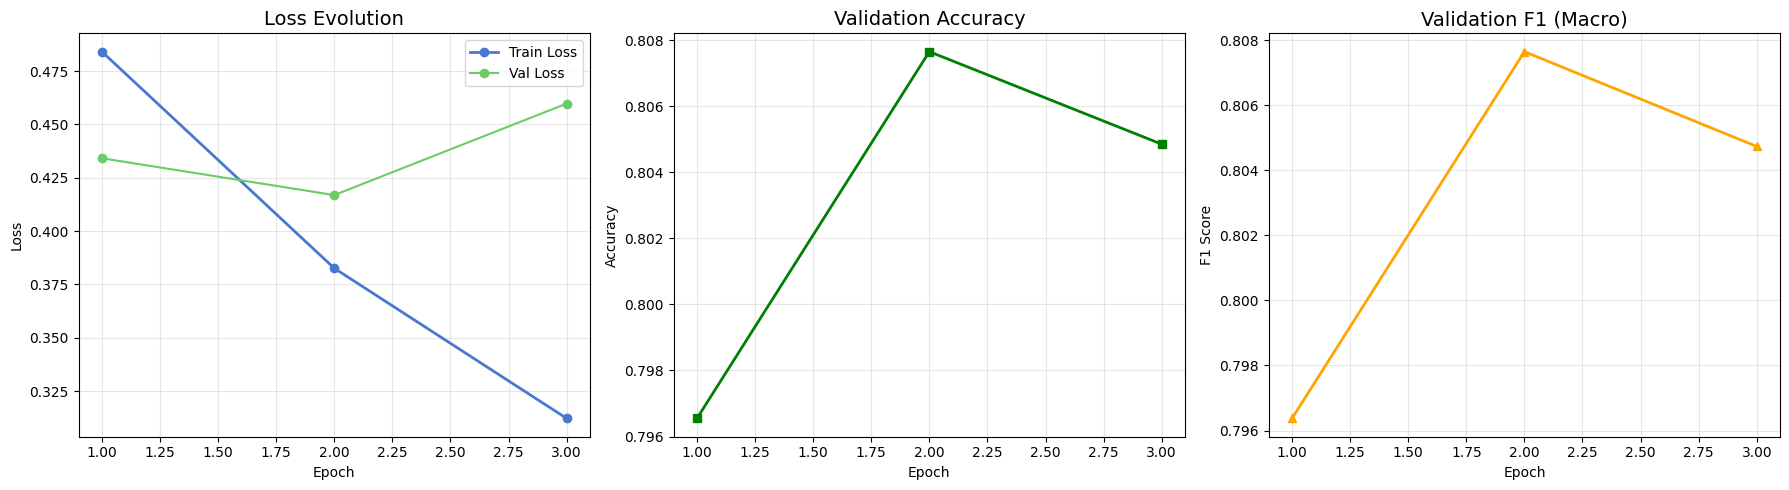

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. График Loss
axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Val Loss', marker='o')
axes[0].set_title('Loss Evolution', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. График Accuracy
axes[1].plot(epochs_range, val_accuracies, color='green', marker='s', linewidth=2)
axes[1].set_title('Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

# 3. График F1-Score
axes[2].plot(epochs_range, val_f1_scores, color='orange', marker='^', linewidth=2)
axes[2].set_title('Validation F1 (Macro)', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].grid(True, alpha=0.3)

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Семинар/Graphics/LSTM/lstm_graph.png', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    for input_ids, labels in loader:
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        out = model(input_ids)
        pred = out.argmax(dim=1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


true_labels, pred_labels = get_all_predictions(model, test_loader, DEVICE)

cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix на тестовой выборке')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def show_misclassified(model, loader, dataset, device, max_examples=20):
    model.eval()

    wrong = []
    idx_global = 0  # индекс в датасете

    for input_ids, labels in loader:
        batch_size = input_ids.size(0)

        input_ids = input_ids.to(device)
        labels = labels.to(device)

        out = model(input_ids)
        preds = out.argmax(dim=1)

        for i in range(batch_size):
            if preds[i] != labels[i]:
                text = dataset.texts[idx_global + i]

                wrong.append({
                    "text": text,
                    "true": labels[i].item(),
                    "pred": preds[i].item()
                })

        idx_global += batch_size

    # вывод
    for i, w in enumerate(wrong[:max_examples]):
        print(f"\n--- Example {i+1} ---")
        print(f"TEXT: {w['text']}")
        print(f"TRUE: {w['true']} | PRED: {w['pred']}")

    print(f"\nВсего ошибок: {len(wrong)}")

    return wrong

In [ ]:
wrong_samples = show_misclassified(
    model,
    test_loader,
    test_dataset,
    DEVICE,
    max_examples=20
)